# Stock Market Data Pipeline and Analysis

## Objective

The objective of this project is to analyze the previous 30 days of stock price data for three Canadian banks:

- Royal Bank of Canada (RY)
- Toronto-Dominion Bank (TD)
- Bank of Nova Scotia (BNS)

The project performs the following tasks:

1. Downloads stock data using the Yahoo Finance API.
2. Extracts adjusted closing prices.
3. Calculates a 7-day rolling average.
4. Calculates daily percentage changes.
5. Flags days where the stock price dropped by more than 2%.
6. Visualizes stock prices and rolling averages.
7. Exports a final report to CSV format.

In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,5)

# Download Stock Data

We download the last 30 days of stock data for:

- RY (Royal Bank of Canada)
- TD (Toronto-Dominion Bank)
- BNS (Bank of Nova Scotia)

Yahoo Finance is used as the data source.

In [2]:
stocks = ["RY", "TD", "BNS"]

df = yf.download(
    stocks,
    period="30d",
    auto_adjust=True
)

df.head()

[*********************100%***********************]  3 of 3 completed


Price           Close                               High              \
Ticker            BNS          RY          TD        BNS          RY   
Date                                                                   
2026-04-29  75.650002  175.220001  104.309998  76.769997  177.639999   
2026-04-30  77.800003  179.970001  107.699997  77.900002  180.220001   
2026-05-01  78.000000  179.539993  107.309998  78.550003  180.899994   
2026-05-04  76.570000  177.929993  106.250000  77.690002  178.910004   
2026-05-05  76.669998  178.479996  105.940002  77.089996  179.710007   

Price                         Low                               Open  \
Ticker              TD        BNS          RY          TD        BNS   
Date                                                                   
2026-04-29  105.660004  75.639999  175.110001  104.309998  76.349998   
2026-04-30  107.800003  75.820000  175.570007  104.669998  75.820000   
2026-05-01  108.349998  77.589996  179.190002  107.309998  77.860001   
2026-05-04  107.620003  76.430000  177.460007  106.000000  77.309998   
2026-05-05  106.800003  76.589996  178.130005  105.760002  76.760002   

Price                                Volume                    
Ticker              RY          TD      BNS       RY       TD  
Date                                                           
2026-04-29  177.639999  105.169998  1996100  1287900  2933700  
2026-04-30  175.570007  104.669998  1777900  1370800  2323900  
2026-05-01  180.130005  107.790001  1242100   604100  2306000  
2026-05-04  178.429993  107.199997  1230600   629400  1434500  
2026-05-05  178.289993  106.500000  1269100   684400   898500

# Examine Dataset Structure

The downloaded dataset contains:

- Open Price
- High Price
- Low Price
- Close Price
- Volume

For this project, only closing prices are required.

In [3]:
print(df.shape)

df.head()

(30, 15)


Price           Close                               High              \
Ticker            BNS          RY          TD        BNS          RY   
Date                                                                   
2026-04-29  75.650002  175.220001  104.309998  76.769997  177.639999   
2026-04-30  77.800003  179.970001  107.699997  77.900002  180.220001   
2026-05-01  78.000000  179.539993  107.309998  78.550003  180.899994   
2026-05-04  76.570000  177.929993  106.250000  77.690002  178.910004   
2026-05-05  76.669998  178.479996  105.940002  77.089996  179.710007   

Price                         Low                               Open  \
Ticker              TD        BNS          RY          TD        BNS   
Date                                                                   
2026-04-29  105.660004  75.639999  175.110001  104.309998  76.349998   
2026-04-30  107.800003  75.820000  175.570007  104.669998  75.820000   
2026-05-01  108.349998  77.589996  179.190002  107.309998  77.860001   
2026-05-04  107.620003  76.430000  177.460007  106.000000  77.309998   
2026-05-05  106.800003  76.589996  178.130005  105.760002  76.760002   

Price                                Volume                    
Ticker              RY          TD      BNS       RY       TD  
Date                                                           
2026-04-29  177.639999  105.169998  1996100  1287900  2933700  
2026-04-30  175.570007  104.669998  1777900  1370800  2323900  
2026-05-01  180.130005  107.790001  1242100   604100  2306000  
2026-05-04  178.429993  107.199997  1230600   629400  1434500  
2026-05-05  178.289993  106.500000  1269100   684400   898500

# Extract Closing Prices

Only the adjusted closing prices are extracted for further analysis.

In [4]:
close_df = df["Close"]

close_df.head()

Ticker,BNS,RY,TD
Date,,,
2026-04-29,75.650002,175.220001,104.309998
2026-04-30,77.800003,179.970001,107.699997
2026-05-01,78.000000,179.539993,107.309998
2026-05-04,76.570000,177.929993,106.250000
2026-05-05,76.669998,178.479996,105.940002


#  Check Missing Values

Missing values can negatively affect calculations.

We verify whether any missing values exist in the dataset.

In [18]:
print("Closing price null values:")
close_df.isnull().sum()

Closing price null values:


Ticker
BNS    0
RY     0
TD     0
dtype: int64

# Calculate 7-Day Rolling Average

A rolling average smooths short-term fluctuations and highlights trends.

Formula:

Rolling Average = Average of Previous 7 Trading Days

In [17]:
rolling_avg = close_df.rolling(window=7).mean()

print("Rolling Average of 7 days:")
rolling_avg.head(10)

Rolling Average of 7 days:


Ticker,BNS,RY,TD
Date,,,
2026-04-29,NaN,NaN,NaN
2026-04-30,NaN,NaN,NaN
2026-05-01,NaN,NaN,NaN
2026-05-04,NaN,NaN,NaN
2026-05-05,NaN,NaN,NaN
2026-05-06,NaN,NaN,NaN
2026-05-07,77.318571,179.159999,106.829999
2026-05-08,77.587142,180.082855,107.279999
2026-05-11,77.478570,180.208570,107.192856


# Calculate Daily Percentage Change

Percentage change measures daily stock returns.

Formula:
$$
\text{Daily Return} = \frac{\text{Current Price} - \text{Previous Price}}{\text{Previous Price}}
$$

In [19]:
daily_change = close_df.pct_change()
print("Daily percentage change:")
daily_change.head()

Daily percentage change:


Ticker,BNS,RY,TD
Date,,,
2026-04-29,NaN,NaN,NaN
2026-04-30,0.028420,0.027109,0.032499
2026-05-01,0.002571,-0.002389,-0.003621
2026-05-04,-0.018333,-0.008967,-0.009878
2026-05-05,0.001306,0.003091,-0.002918


# Flag Significant Price Drops

A flag is created whenever the stock price decreases by more than 2% in a single day.

Condition:

Percentage Change < -0.02

In [20]:
drop_flag = daily_change < -0.02
print("Drop Flag (True if drop > 2%):")
drop_flag.head()

Drop Flag (True if drop > 2%):


Ticker,BNS,RY,TD
Date,,,
2026-04-29,False,False,False
2026-04-30,False,False,False
2026-05-01,False,False,False
2026-05-04,False,False,False
2026-05-05,False,False,False


# Create Final Analysis Report

The report contains:

- Closing Price
- 7-Day Rolling Average
- Drop Flag Indicator


In [21]:
report = close_df.copy()

for stock in stocks:
    
    report[f"{stock}_7Day_Avg"] = rolling_avg[stock]
    
    report[f"{stock}_Drop_Flag"] = drop_flag[stock]

print("Final Report")
report.head(10)

Final Report


Ticker,BNS,RY,TD,RY_7Day_Avg,RY_Drop_Flag,TD_7Day_Avg,TD_Drop_Flag,BNS_7Day_Avg,BNS_Drop_Flag
Date,,,,,,,,,
2026-04-29,75.650002,175.220001,104.309998,NaN,False,NaN,False,NaN,False
2026-04-30,77.800003,179.970001,107.699997,NaN,False,NaN,False,NaN,False
2026-05-01,78.000000,179.539993,107.309998,NaN,False,NaN,False,NaN,False
2026-05-04,76.570000,177.929993,106.250000,NaN,False,NaN,False,NaN,False
2026-05-05,76.669998,178.479996,105.940002,NaN,False,NaN,False,NaN,False
2026-05-06,78.449997,181.630005,108.599998,NaN,False,NaN,False,NaN,False
2026-05-07,78.089996,181.350006,107.699997,179.159999,False,106.829999,False,77.318571,False
2026-05-08,77.529999,181.679993,107.459999,180.082855,False,107.279999,False,77.587142,False
2026-05-11,77.040001,180.850006,107.089996,180.208570,False,107.192856,False,77.478570,False


# Export Report

The final report is saved as a CSV file for future analysis.

In [ ]:
report.to_csv("stock_report.csv")

print("Report saved successfully.")

# Visualize Stock Prices

The following charts compare:

- Actual Closing Price
- 7-Day Rolling Average

for each stock.

In [22]:
pip install seaborn


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [25]:
import seaborn as sns
sns.set_theme(style="whitegrid")

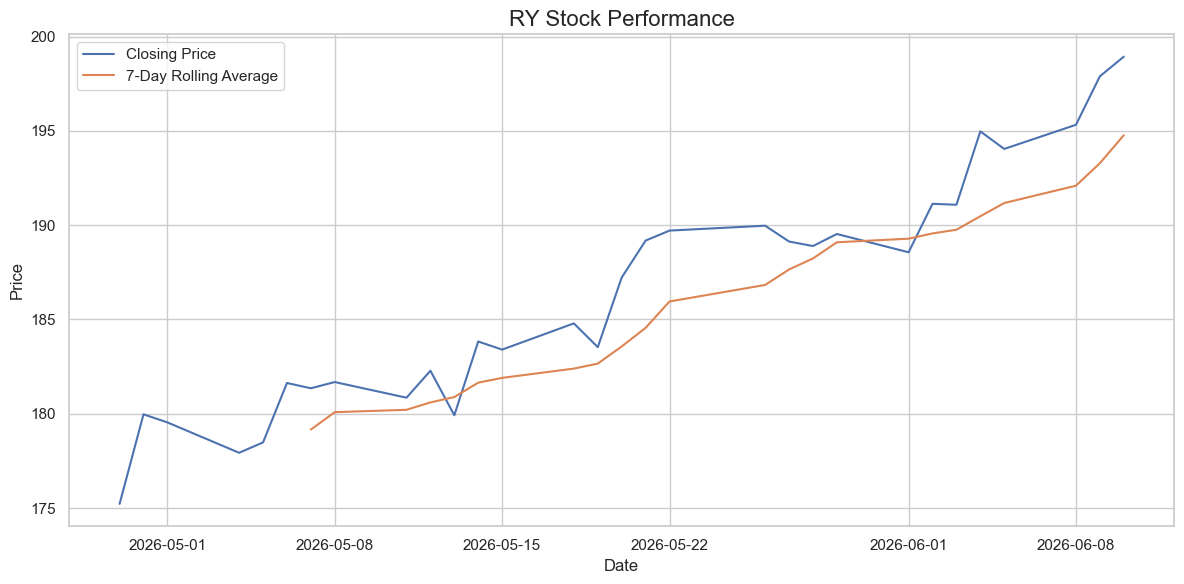

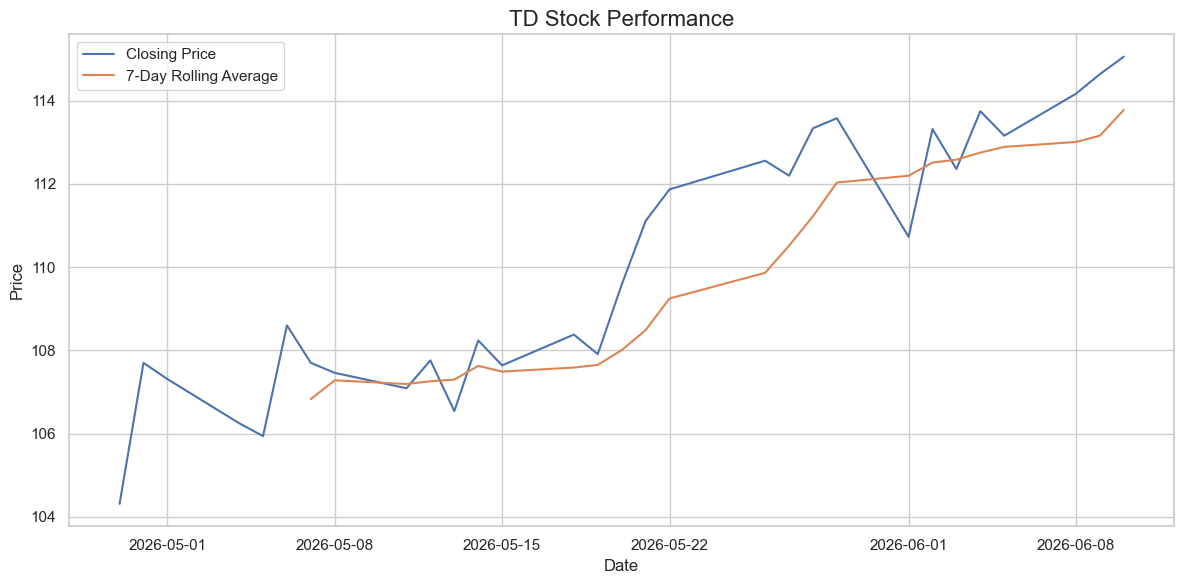

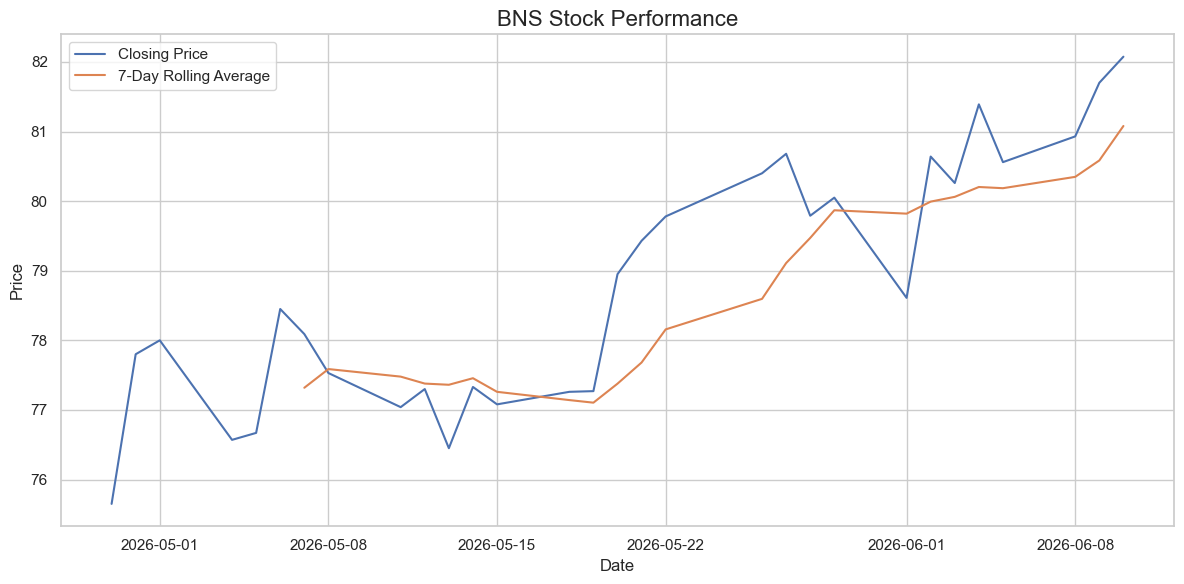

In [26]:
for stock in stocks:

    plt.figure(figsize=(12,6))

    sns.lineplot(
        x=close_df.index,
        y=close_df[stock],
        label="Closing Price"
    )

    sns.lineplot(
        x=rolling_avg.index,
        y=rolling_avg[stock],
        label="7-Day Rolling Average"
    )

    plt.title(f"{stock} Stock Performance", fontsize=16)

    plt.xlabel("Date")
    plt.ylabel("Price")

    plt.legend()

    plt.tight_layout()

    plt.show()

## Daily Return Distribution

This histogram shows the distribution of daily stock returns.

The graph helps identify:

- The most common daily return values.
- Whether returns are centered around zero.
- The frequency of positive and negative returns.
- The overall behavior of stock price movements.

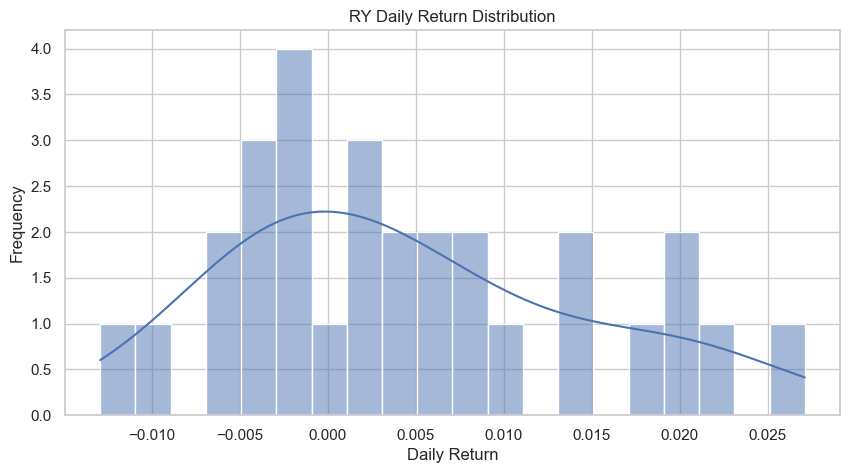

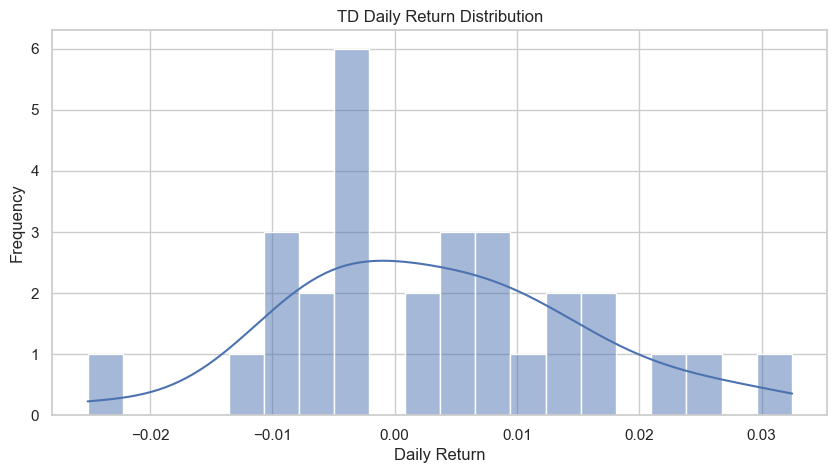

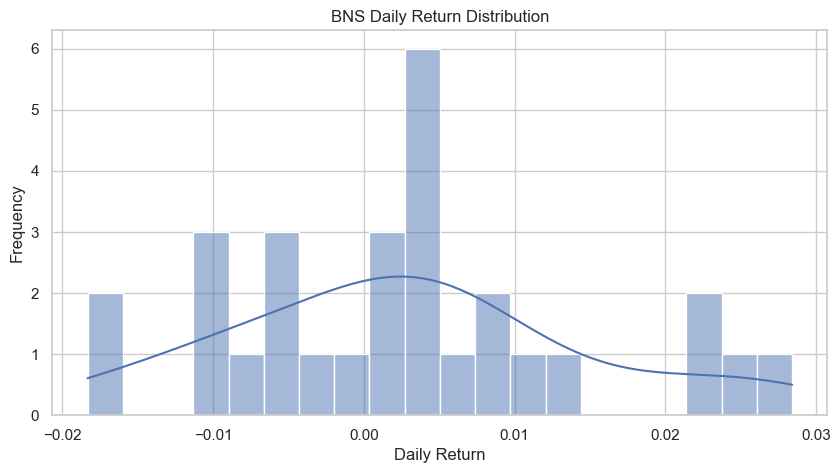

In [28]:
for stock in stocks:

    plt.figure(figsize=(10,5))

    sns.histplot(
        daily_change[stock].dropna(),
        bins=20,
        kde=True
    )

    plt.title(f"{stock} Daily Return Distribution")
    plt.xlabel("Daily Return")
    plt.ylabel("Frequency")

    plt.show()

## Stock Correlation Heatmap

The correlation heatmap measures the relationship between stock prices.

Correlation values range from:

- +1 : Perfect positive relationship
- 0 : No relationship
- -1 : Perfect negative relationship

A high positive correlation indicates that the stocks tend to move in the same direction.

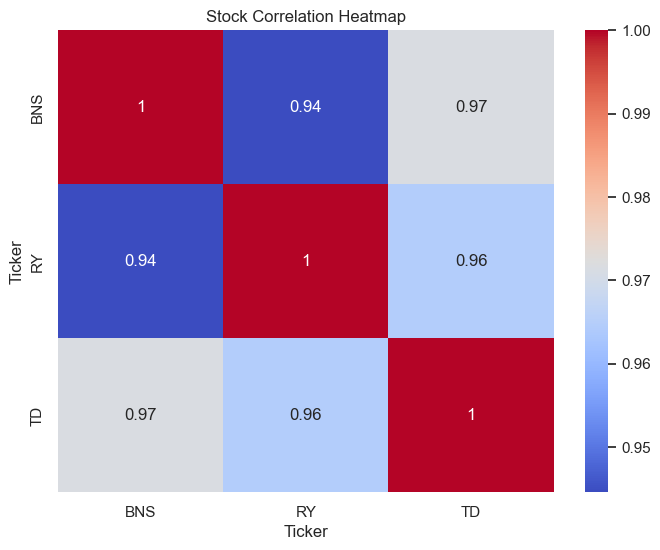

In [29]:
plt.figure(figsize=(8,6))

sns.heatmap(
    close_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Stock Correlation Heatmap")

plt.show()

## Daily Percentage Change

This graph displays daily percentage changes in stock prices.

The visualization helps identify:

- Volatile trading days
- Positive and negative returns
- Short-term market movements
- Differences in stock performance over time

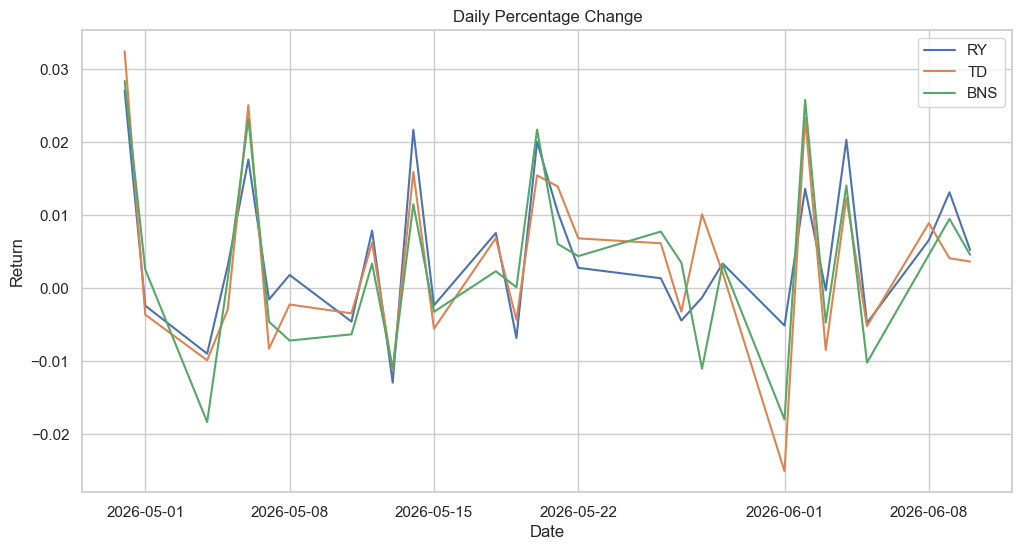

In [30]:
plt.figure(figsize=(12,6))

for stock in stocks:

    sns.lineplot(
        x=daily_change.index,
        y=daily_change[stock],
        label=stock
    )

plt.title("Daily Percentage Change")
plt.xlabel("Date")
plt.ylabel("Return")

plt.show()

## Distribution of Daily Returns (Box Plot)

The box plot summarizes the distribution of daily returns.

It provides information about:

- Median return
- Spread of returns
- Volatility
- Outliers and extreme market movements

Stocks with larger spreads generally exhibit higher volatility.

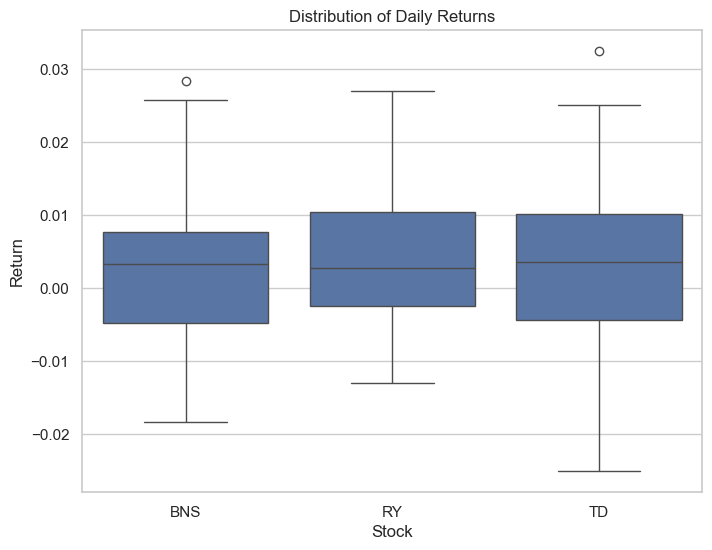

In [32]:
returns = daily_change.melt(
    var_name="Stock",
    value_name="Return"
)

plt.figure(figsize=(8,6))

sns.boxplot(
    data=returns,
    x="Stock",
    y="Return"
)

plt.title("Distribution of Daily Returns")

plt.show()

## Pairwise Relationship Analysis

The pair plot examines pairwise relationships among stock returns.

It combines:

- Scatter plots
- Histograms
- Distribution analysis

This visualization helps identify whether stocks move together and reveals patterns that may not be visible in individual charts.

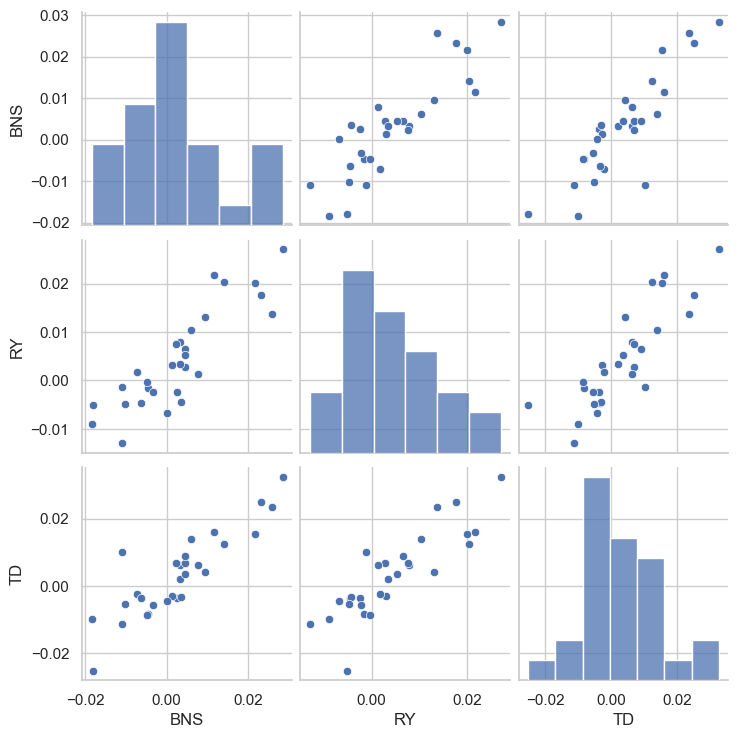

In [33]:
sns.pairplot(
    daily_change.dropna()
)

plt.show()

# Save Charts

The generated charts are saved as PNG images.

In [35]:
for stock in stocks:

    plt.figure(figsize=(12,6))

    sns.lineplot(
        x=close_df.index,
        y=close_df[stock],
        label="Closing Price"
    )

    sns.lineplot(
        x=rolling_avg.index,
        y=rolling_avg[stock],
        label="7-Day Rolling Average"
    )

    plt.title(f"{stock} Stock Performance")

    plt.savefig(f"{stock}_performance.png")

    plt.close()

In [12]:
for stock in stocks:

    plt.figure()

    plt.plot(
        close_df[stock],
        label="Closing Price"
    )

    plt.plot(
        rolling_avg[stock],
        label="7-Day Rolling Average"
    )

    plt.title(f"{stock} Stock Analysis")

    plt.xlabel("Date")

    plt.ylabel("Price")

    plt.legend()

    plt.grid(True)

    plt.savefig(f"{stock}_chart.png")

    plt.close()

print("Charts saved successfully.")

Charts saved successfully.


# Conclusion

This project demonstrates:

- Financial data collection using APIs
- Data preprocessing with Pandas
- Time-series analysis
- Rolling average calculation
- Percentage change analysis
- Risk event detection
- Data visualization

The analysis provides a simple monitoring system for stock performance and can be extended to support additional companies, longer time periods, and automated reporting.